# 📊 Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore engine operational data and identify patterns that can help improve equipment reliability and maintenance planning.

The analysis focuses on answering business questions through data visualization and statistical summaries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/aeroengine_cleaned.csv")

In [3]:
df.head()

,Engine_ID,Cycle,Operational_Setting_1,Operational_Setting_2,Sensor_2,Sensor_3,Sensor_4,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_17,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [4]:
engine_life = df.groupby("Engine_ID")["Cycle"].max().reset_index()
engine_life.head()

,Engine_ID,Cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


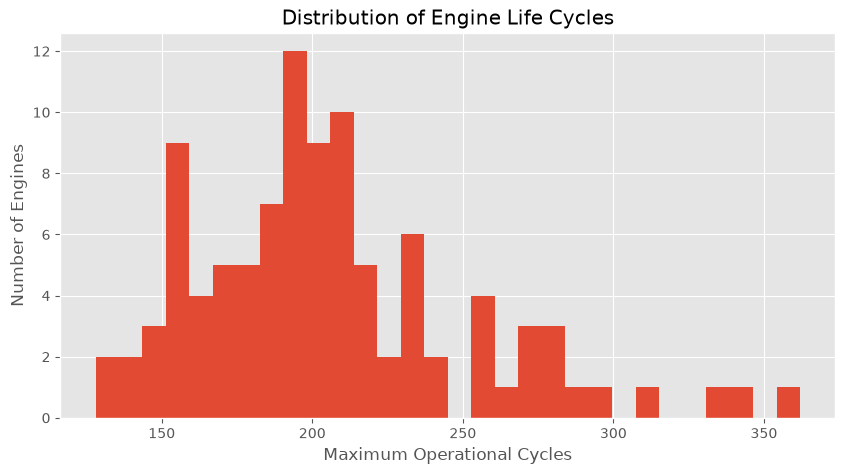

In [5]:
plt.figure(figsize=(10,5))
plt.hist(engine_life["Cycle"], bins=30)
plt.title("Distribution of Engine Life Cycles")
plt.xlabel("Maximum Operational Cycles")
plt.ylabel("Number of Engines")
plt.show()

### Business Insight

Engine operational life varies across engines, indicating differences in degradation patterns.

Understanding this variation is important for maintenance scheduling and Remaining Useful Life (RUL) estimation.

In [6]:
sensor_variance = df.iloc[:,5:].var().sort_values(ascending=False)
sensor_variance.head(10)

Sensor_9     487.653568
Sensor_14    363.900490
Sensor_4      81.010886
Sensor_3      37.590994
Sensor_17      2.398667
Sensor_7       0.783388
Sensor_12      0.543985
Sensor_11      0.071336
Sensor_20      0.032669
Sensor_21      0.011718
dtype: float64

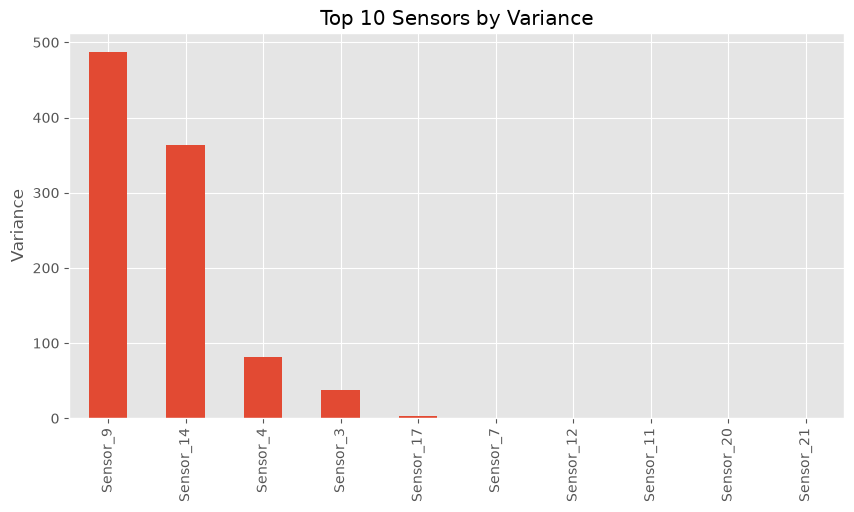

In [7]:
plt.figure(figsize=(10,5))
sensor_variance.head(10).plot(kind="bar")
plt.title("Top 10 Sensors by Variance")
plt.ylabel("Variance")
plt.show()

### Business Insight

Sensors with higher variance capture more changes in engine operating conditions and may provide stronger indicators of degradation.

In [8]:
sensor_variance.tail(10)

Sensor_17    2.398667
Sensor_7     0.783388
Sensor_12    0.543985
Sensor_11    0.071336
Sensor_20    0.032669
Sensor_21    0.011718
Sensor_13    0.005172
Sensor_8     0.005039
Sensor_15    0.001407
Sensor_6     0.000002
dtype: float64

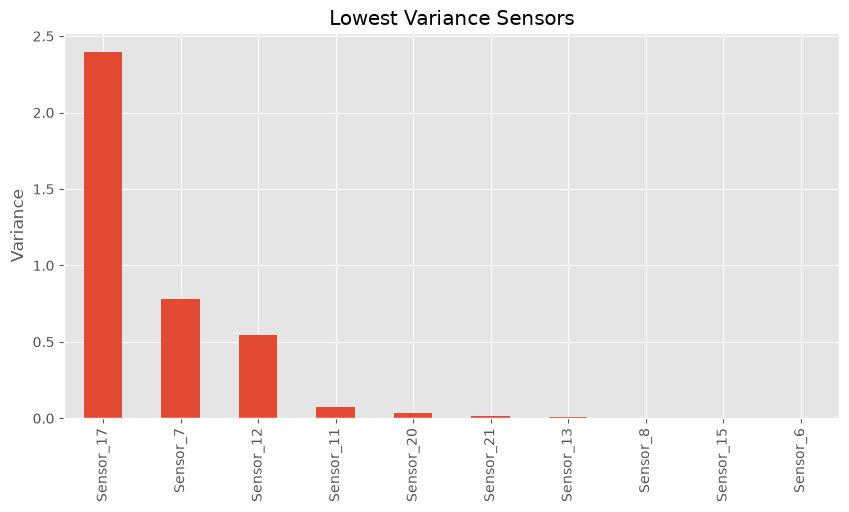

In [9]:
plt.figure(figsize=(10,5))
sensor_variance.tail(10).plot(kind="bar")
plt.title("Lowest Variance Sensors")
plt.ylabel("Variance")
plt.show()

### Business Insight

Low-variance sensors exhibit minimal change during engine operation and may contribute less information for predictive maintenance.

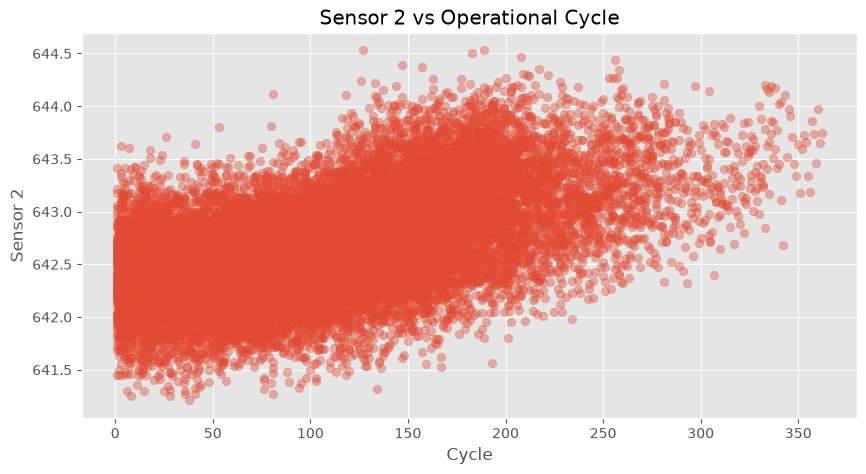

In [10]:
plt.figure(figsize=(10,5))
plt.scatter(df["Cycle"], df["Sensor_2"], alpha=0.4)
plt.title("Sensor 2 vs Operational Cycle")
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.show()

### Business Insight

Sensor readings evolve as engines accumulate operational cycles, suggesting a relationship between equipment usage and sensor behavior.

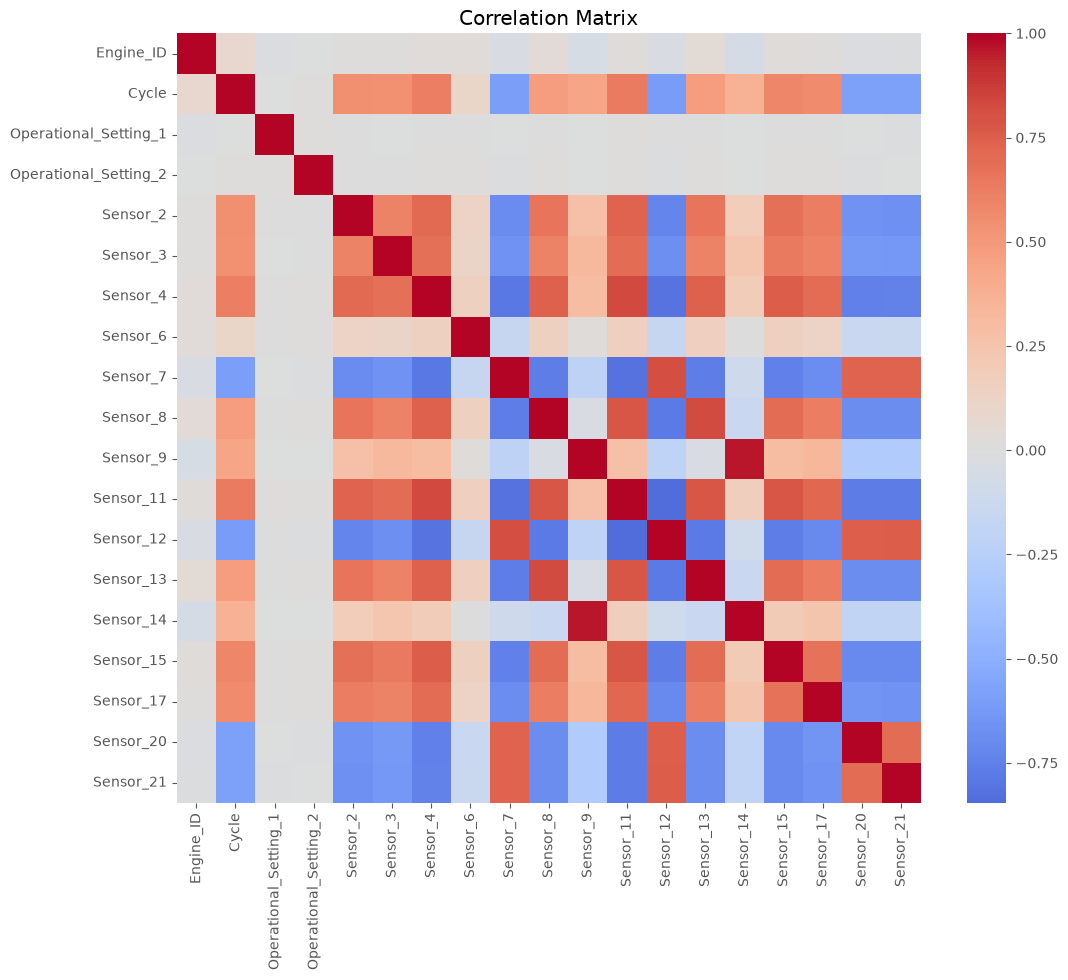

In [11]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Business Insight

Several sensors demonstrate strong correlations, indicating that they may capture related aspects of engine performance.

# Final Observation Table

| Business Question    | Status | Key Finding                         |
| -------------------- | ------ | ----------------------------------- |
| Engine Life Analysis | ✅      | Engine life varies across units     |
| Sensor Variance      | ✅      | High-variance sensors identified    |
| Low Variance Sensors | ✅      | Less informative sensors identified |
| Sensor Trends        | ✅      | Sensor behavior changes with cycles |
| Correlation Analysis | ✅      | Several correlated sensor groups    |
